In [6]:
import matplotlib.pyplot as plt
import numpy as np
import pyreadr
from cmdstanpy import CmdStanModel

In [15]:
df = pyreadr.read_r('data/OD_all_ICs.Rda')[None]
df['missing_data'] = df['OD'].isna()
df['training_data'] = True
df['testing_data'] = False
df = df.loc[df['training_data'] | df['testing_data']]
df['training_data'] = df['training_data'] & ~df['missing_data']
df['testing_data'] = df['testing_data'] & ~df['missing_data']
df.head().style.hide(axis='index')

time,temp,OD,ID,fungal_ic,technical_reps,biological_reps,blanks,missing_data,training_data,testing_data
0.000000,30.500000,0.120000,1.000000,0.000000,R1,1.000000,True,False,True,False
1.000000,37.000000,0.122000,1.000000,0.000000,R1,1.000000,True,False,True,False
2.000000,37.000000,0.124000,1.000000,0.000000,R1,1.000000,True,False,True,False
3.000000,37.000000,0.125000,1.000000,0.000000,R1,1.000000,True,False,True,False
4.000000,37.000000,0.125000,1.000000,0.000000,R1,1.000000,True,False,True,False


In [149]:
df[df['training_data']]

,time,temp,OD,ID,fungal_ic,technical_reps,biological_reps,blanks,missing_data,training_data,testing_data
0,0.0,30.5,0.120,1.0,0.0,R1,1.0,True,False,True,False
1,1.0,37.0,0.122,1.0,0.0,R1,1.0,True,False,True,False
2,2.0,37.0,0.124,1.0,0.0,R1,1.0,True,False,True,False
3,3.0,37.0,0.125,1.0,0.0,R1,1.0,True,False,True,False
4,4.0,37.0,0.125,1.0,0.0,R1,1.0,True,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...
1165,21.0,37.0,0.304,45.0,200000.0,R3,3.0,False,False,True,False
1166,22.0,37.0,0.324,45.0,200000.0,R3,3.0,False,False,True,False
1167,23.0,37.0,0.346,45.0,200000.0,R3,3.0,False,False,True,False
1168,24.0,37.0,0.367,45.0,200000.0,R3,3.0,False,False,True,False


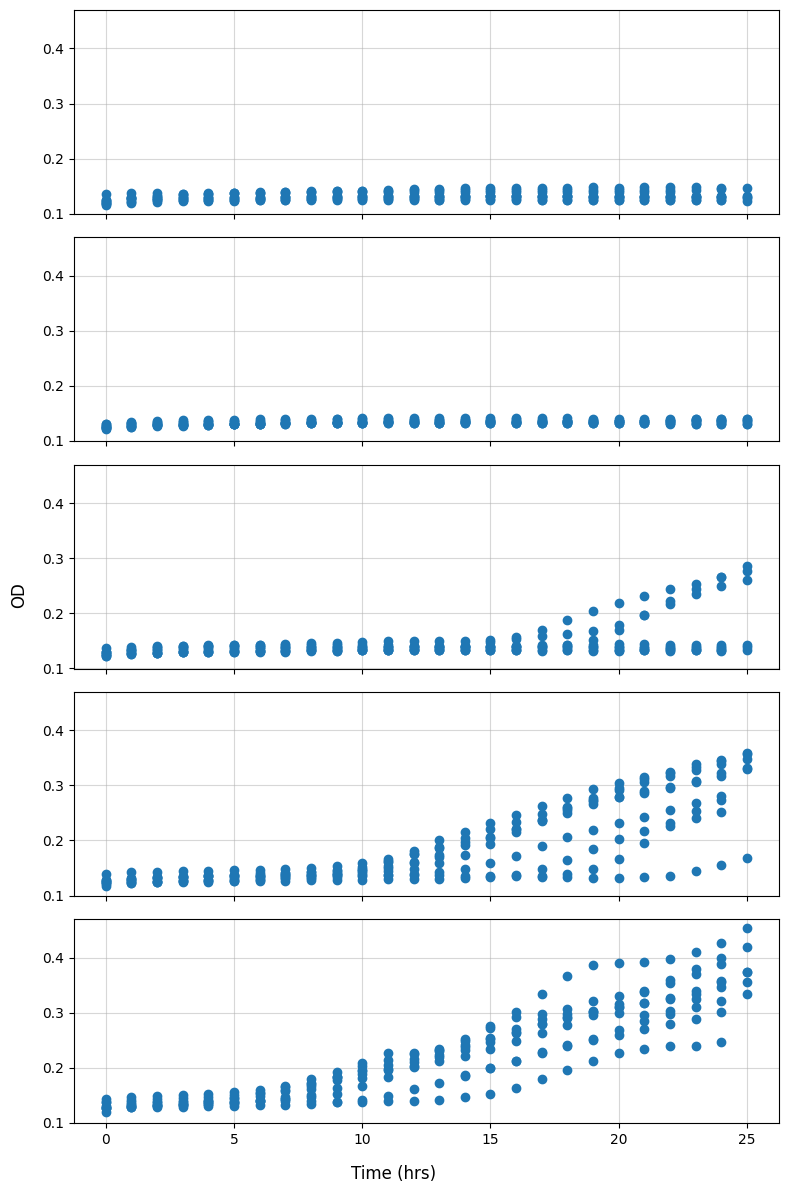

In [151]:
ics = (fungal_ic := df[df['training_data']]['fungal_ic']).unique()
fig, axes = plt.subplots(len(ics), sharex=True, sharey=True, figsize=(8, 12))

for ax, ic in zip(axes, ics):
    ax.grid(alpha=.5)
    idx = np.where(fungal_ic == ic)[0]
    ax.scatter(df.iloc[idx]['time'], df.iloc[idx]['OD'], zorder=2)

fig.supxlabel('Time (hrs)')
fig.supylabel('OD')
fig.tight_layout()

In [152]:
stan_data = {
    'N_obs': df['training_data'].sum().item(),
    'N_miss': df['missing_data'].sum().item(),
    'N_pred': df['testing_data'].sum().item(),
    'N_c': df['blanks'].sum().item(),
    'N_exp': len(df) - df['blanks'].sum().item(),
    'c_idx': [i.item() + 1 for i in np.where(df['blanks'])[0]],
    'exp_idx': [i.item() + 1 for i in np.where(~df['blanks'])[0]],
    'y_train_idx': [i.item() + 1 for i in np.where(df['training_data'])[0]],
    'y_missing_idx': [i.item() + 1 for i in np.where(df['missing_data'])[0]],
    'y_test_idx': [i.item() + 1 for i in np.where(df['testing_data'])[0]],
    'IC': df['fungal_ic'],
    'y_obs_train': df['OD'][df['training_data']],
    'y_obs_test': df['OD'][df['testing_data']],
    'time': df['time'],
    'mu_0': 1,
    'include_likelihood': True
}

In [153]:
model = CmdStanModel(stan_file='../terrarium/models/fungi.stan')
fit = model.sample(stan_data, chains=4)

13:53:25 - cmdstanpy - INFO - CmdStan start processing


chain 1:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

chain 2:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

chain 3:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

chain 4:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

13:53:45 - cmdstanpy - INFO - CmdStan done processing.
13:53:45 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: lognormal_lpdf: Scale parameter is inf, but must be positive finite! (in 'fungi.stan', line 85, column 8 to column 65)
	Exception: lognormal_lpdf: Scale parameter is inf, but must be positive finite! (in 'fungi.stan', line 85, column 8 to column 65)
	Exception: lognormal_lpdf: Scale parameter is inf, but must be positive finite! (in 'fungi.stan', line 85, column 8 to column 65)
	Exception: gamma_lpdf: Random variable is inf, but must be positive finite! (in 'fungi.stan', line 77, column 4 to column 22)
	Exception: lognormal_lpdf: Scale parameter is inf, but must be positive finite! (in 'fungi.stan', line 85, column 8 to column 65)
Exception: lognormal_lpdf: Scale parameter is inf, but must be positive finite! (in 'fungi.stan', line 85, column 8 to column 65)
	Exception: lognormal_lpdf: Scale parameter is inf, but must be positive finite! (in 'fungi.stan', 

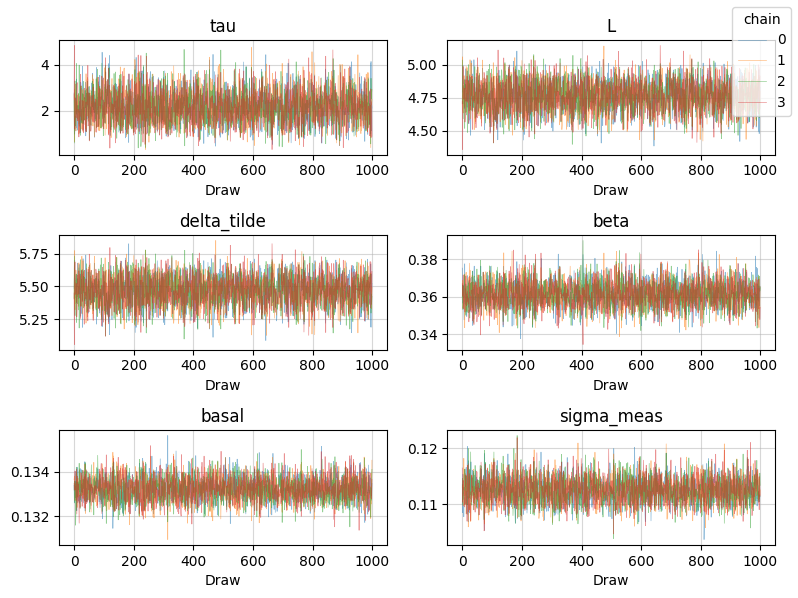

In [154]:
params = ('tau', 'L', 'delta_tilde', 'beta', 'basal', 'sigma_meas')
n_draws = len(draws := fit.draws_pd())
n_chains = len(draws['chain__'].unique())
fig, axes = plt.subplots(round(len(params)/2), 2, figsize=(8, 6))

for ax, param in zip(axes.flatten(), params):
    ax.grid(alpha=.5)
    param_draws = draws[param].to_numpy().reshape(n_draws//n_chains, n_chains)
    param_lines = ax.plot(param_draws, alpha=.5, linewidth=.5)
    ax.set(title=param, xlabel='Draw')

fig.legend(param_lines, np.arange(n_chains), title='chain')
fig.tight_layout()

In [155]:
fit.summary().head(7)[1:]

,Mean,MCSE,StdDev,MAD,5%,50%,95%,ESS_bulk,ESS_tail,ESS_bulk/s,R_hat
tau,2.177200,0.014704,0.739610,0.764643,1.032760,2.155780,3.440510,2560.81,2793.23,60.0227,0.999967
L,4.761840,0.002446,0.119429,0.122980,4.561060,4.765100,4.957070,2414.92,2772.31,56.6031,1.002480
delta_tilde,5.467160,0.002435,0.118549,0.124567,5.269600,5.469100,5.658920,2403.21,2771.41,56.3287,1.001990
beta,0.361443,0.000095,0.007070,0.006901,0.350016,0.361414,0.373121,5567.25,2622.09,130.4910,1.001720
basal,0.133226,0.000007,0.000559,0.000569,0.132323,0.133214,0.134146,6433.56,2479.31,150.7960,1.004040
sigma_meas,0.112532,0.000035,0.002391,0.002377,0.108709,0.112482,0.116402,4705.33,2614.16,110.2880,1.000440


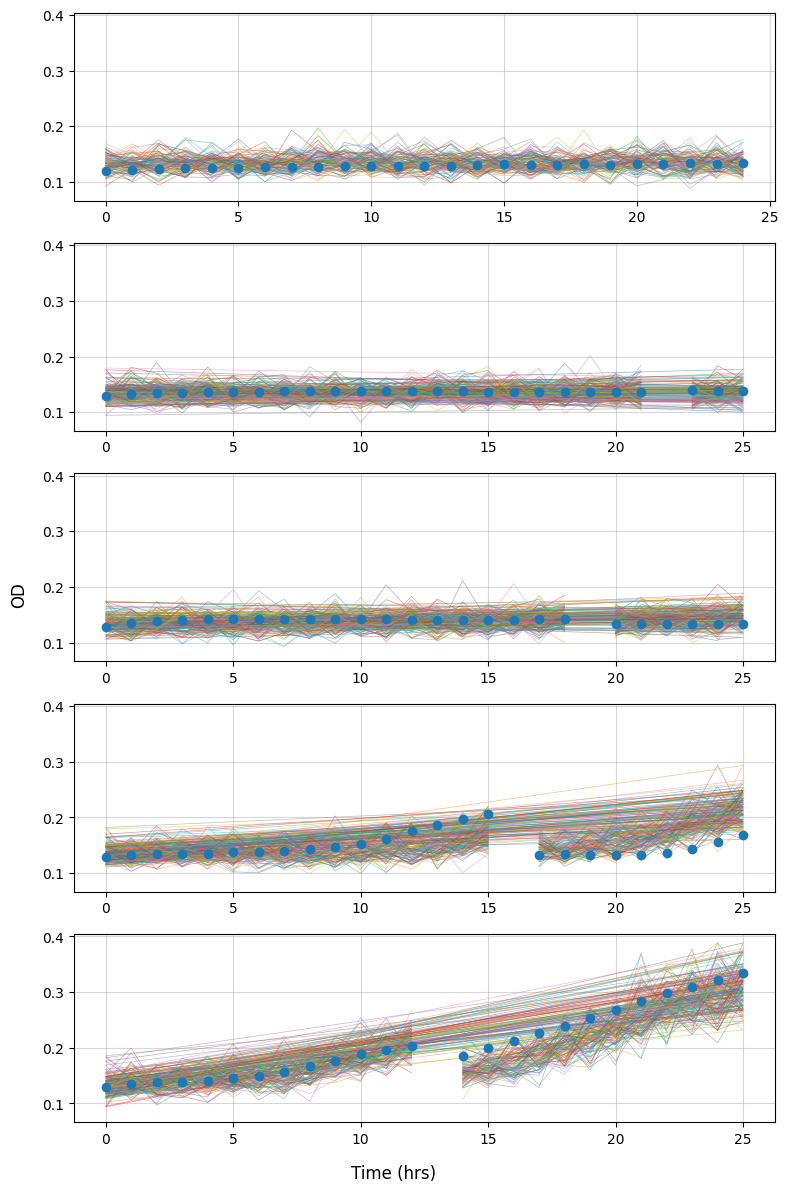

In [282]:
sample_idx = np.random.randint(0, n_draws, 100)
fig, axes = plt.subplots(len(ics), sharex=False, sharey=True, figsize=(8, 12))

for ax, ic in zip(axes, ics):
    ax.grid(alpha=.5)
    idx = np.where(fungal_ic == ic)[0][:25]
    keys = np.array([f'y_tot[{i + 1}]' for i in idx])
    z = draws[keys].loc[sample_idx].T.to_numpy()
    ax.plot(df.iloc[idx]['time'], z, alpha=.5, linewidth=.5)
    ax.scatter(df.iloc[idx]['time'], df.iloc[idx]['OD'], zorder=2)

fig.supxlabel('Time (hrs)')
fig.supylabel('OD')
fig.tight_layout()